In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
DATASET_PATH_1 = "/content/drive/MyDrive/Google AI Studio/cat_vocals/CAT_DB"
DATASET_PATH_2="/content/drive/MyDrive/Google AI Studio/cat_img"

In [10]:
print("Audio Folder:", DATASET_PATH_1)
print("Image Folder:", DATASET_PATH_2)

Audio Folder: /content/drive/MyDrive/Google AI Studio/cat_vocals/CAT_DB
Image Folder: /content/drive/MyDrive/Google AI Studio/cat_img


In [4]:
!pip install librosa soundfile noisereduce
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import cv2
import noisereduce as nr
from PIL import Image
from IPython.display import display


In [5]:
RAW_IMG = "/content/drive/MyDrive/Google AI Studio/cat_img"
CLEAN_IMG = "/content/cat_images_clean"
os.makedirs(CLEAN_IMG, exist_ok=True)

TARGET_SIZE = (224, 224)

def is_blurry(img, threshold=100):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    variance = cv2.Laplacian(gray, cv2.CV_64F).var()
    return variance < threshold

def image_hash(img):
    thumb = cv2.resize(img, (32,32))
    return str(np.mean(thumb))

for cls in os.listdir(RAW_IMG):
    cls_path = os.path.join(RAW_IMG, cls)
    out_cls = os.path.join(CLEAN_IMG, cls)
    os.makedirs(out_cls, exist_ok=True)

    seen = set()
    print("Processing:", cls)

    for f in os.listdir(cls_path):
        path = os.path.join(cls_path, f)
        img = cv2.imread(path)

        if img is None: continue

        if is_blurry(img):
            print("Blurry removed:", f)
            continue

        h = image_hash(img)
        if h in seen:
            print("Duplicate removed:", f)
            continue
        seen.add(h)

        resized = cv2.resize(img, TARGET_SIZE)
        cv2.imwrite(os.path.join(out_cls, f), resized)


Processing: Happy
Duplicate removed: 18_h_jpeg.rf.19814f73d6188dcf0f27db9e633960fb.jpg
Duplicate removed: 13_h_jpeg.rf.d40035292362718be6ba71621c6bb9dd.jpg
Duplicate removed: 44_h_jpeg.rf.af3285b1852fda183e46818cf137dd90.jpg
Blurry removed: 76_h_jpeg.rf.9f83b5015a050e8994da71d4537c2393.jpg
Duplicate removed: 58_h_jpeg.rf.85cd4bdeec47605f7930dee7bd5d6722.jpg
Duplicate removed: 51_h_jpeg.rf.e814c9b0435b95441d29ba373a287da7.jpg
Blurry removed: 92_h_jpeg.rf.04505c4fdd71a1b586cc9413d5f6cc68.jpg
Duplicate removed: 56_h_jpeg.rf.92679dc8beabf337dfe1699c553e53cd.jpg
Duplicate removed: 99_h_jpeg.rf.9f6f6c680e17ded3781ddee150536089.jpg
Duplicate removed: 5_h_jpeg.rf.6d4219a8307bc09fbcde35a9bf6a861c.jpg
Processing: Normal
Duplicate removed: 15_n_jpeg.rf.1566fc41f8636776ebd67cec0837b7a0.jpg
Duplicate removed: 4_n_jpeg.rf.043dfc071719b294ffc9c2cf2a5dfec4.jpg
Duplicate removed: 22_n_jpeg.rf.ca04b369ab1d4b3655442081ad5f2fc3.jpg
Duplicate removed: 46_n_jpeg.rf.08595503791d74159e26cc60c3d160d1.jpg
Dupli

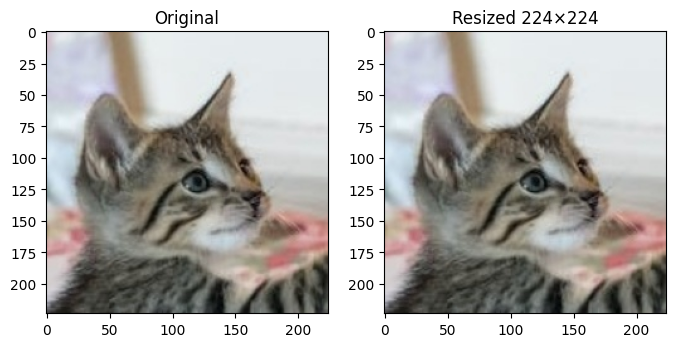

In [6]:
sample = "/content/drive/MyDrive/Google AI Studio/cat_img/Happy/012.jpg"  # change this
img = cv2.imread(sample)
resized = cv2.resize(img, TARGET_SIZE)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)); plt.title("Resized 224×224")
plt.show()


Found 1750 images belonging to 9 classes.


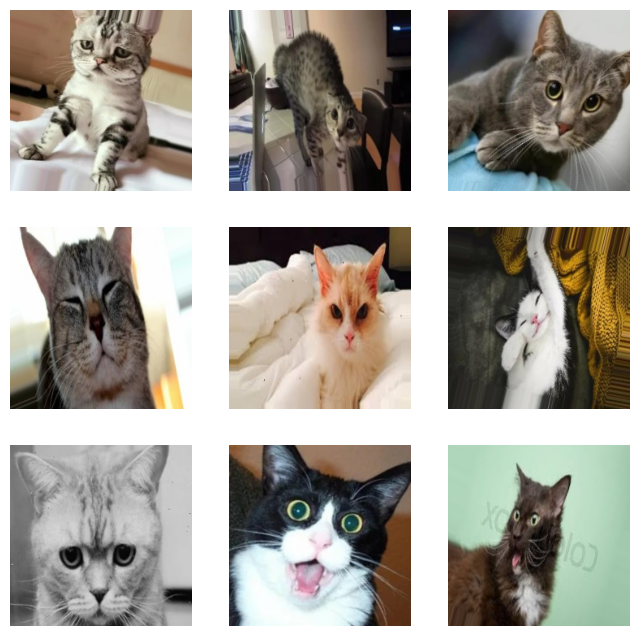

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

gen = datagen.flow_from_directory(
    CLEAN_IMG,
    target_size=(224,224),
    batch_size=9
)

batch, labels = next(gen)

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(batch[i])
    plt.axis("off")
plt.show()


In [12]:
import soundfile as sf


In [13]:
RAW_AUDIO = "/content/drive/MyDrive/Google AI Studio/cat_vocals/CAT_DB"
CLEAN_AUDIO = "/content/cat_audio_clean"
os.makedirs(CLEAN_AUDIO, exist_ok=True)

def preprocess_audio(in_path, out_path):
    y, sr = librosa.load(in_path, sr=16000)
    y_trim, _ = librosa.effects.trim(y)
    y_denoise = nr.reduce_noise(y=y_trim, sr=sr)
    sf.write(out_path, y_denoise, sr)

for cls in os.listdir(RAW_AUDIO):
    cls_path = os.path.join(RAW_AUDIO, cls)
    out_cls = os.path.join(CLEAN_AUDIO, cls)
    os.makedirs(out_cls, exist_ok=True)

    for f in os.listdir(cls_path):
        preprocess_audio(
            os.path.join(cls_path, f),
            os.path.join(out_cls, f.replace(".mp3", ".wav"))
        )


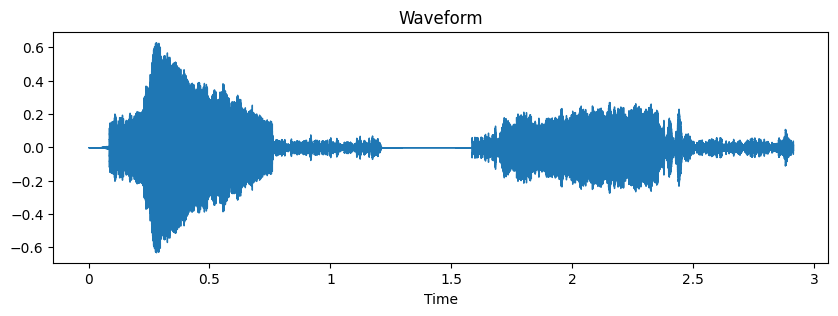

In [14]:
sample_audio = "/content/drive/MyDrive/Google AI Studio/cat_vocals/CAT_DB/Happy/cat_15.mp3"  # change

y, sr = librosa.load(sample_audio, sr=16000)

plt.figure(figsize=(10,3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.show()


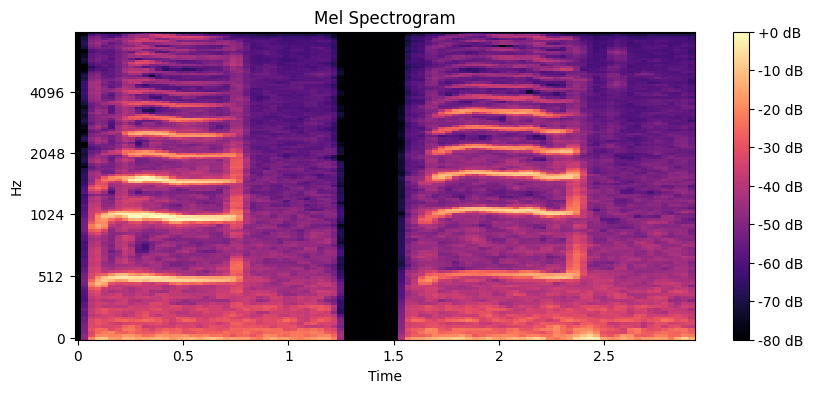

In [15]:
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.f dB")
plt.title("Mel Spectrogram")
plt.show()


In [16]:
def transform_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (224,224))
    img = img.astype("float32") / 255.0
    return img


In [17]:
def audio_to_spec(path):
    y, sr = librosa.load(path, sr=16000)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    return librosa.power_to_db(S, ref=np.max)


In [18]:
import tensorflow as tf
from tensorflow.keras import layers, Model

img_in = layers.Input(shape=(224,224,3))
audio_in = layers.Input(shape=(128,128,1))

# pretend we already extracted image features
f_img = layers.Flatten()(img_in)
f_audio = layers.Flatten()(audio_in)

combined = layers.concatenate([f_img, f_audio])
x = layers.Dense(128, activation='relu')(combined)
out = layers.Dense(4, activation='softmax')(x)

model = Model([img_in, audio_in], out)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 150528)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16384)     │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 166912)    │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │ 21,364,864 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        516 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,365,380 (81.50 MB)

 Trainable params: 21,365,380 (81.50 MB)

 Non-trainable params: 0 (0.00 B)

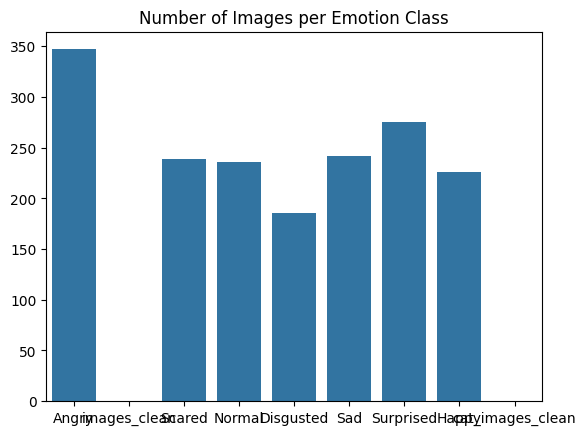

In [19]:
import seaborn as sns

counts = {}
for cls in os.listdir(CLEAN_IMG):
    counts[cls] = len(os.listdir(os.path.join(CLEAN_IMG, cls)))

sns.barplot(x=list(counts.keys()), y=list(counts.values()))
plt.title("Number of Images per Emotion Class")
plt.show()


/tmp/ipython-input-2132337209.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(durations.values(), labels=durations.keys())


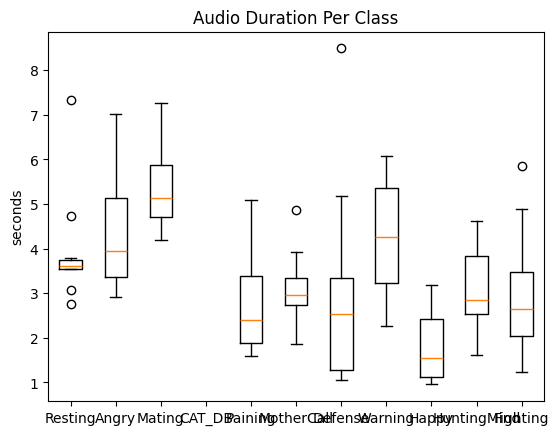

In [20]:
durations = {}

for cls in os.listdir(CLEAN_AUDIO):
    cls_path = os.path.join(CLEAN_AUDIO, cls)
    ds = []
    for f in os.listdir(cls_path):
        y, sr = librosa.load(os.path.join(cls_path, f), sr=16000)
        ds.append(len(y)/sr)
    durations[cls] = ds

plt.boxplot(durations.values(), labels=durations.keys())
plt.title("Audio Duration Per Class")
plt.ylabel("seconds")
plt.show()


🎵 Plotting for: /content/cat_audio_clean/Resting/cat_coll0110.wav


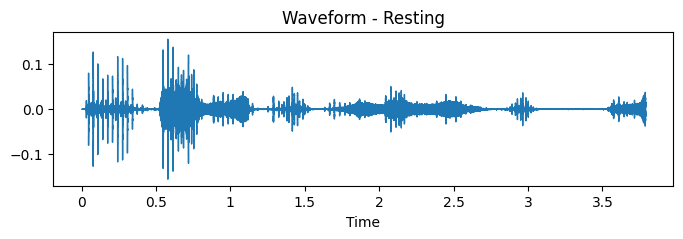

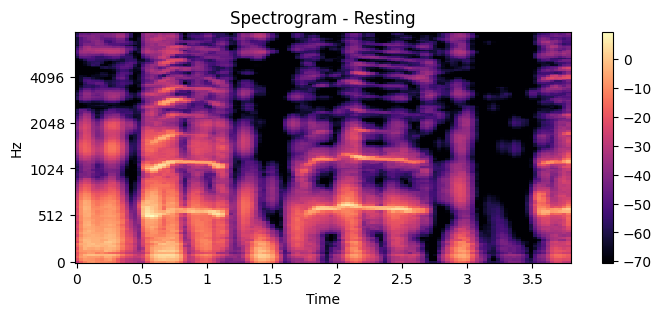

🎵 Plotting for: /content/cat_audio_clean/Angry/car_extcoll0172.wav


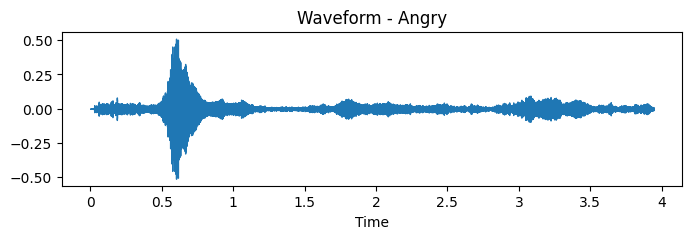

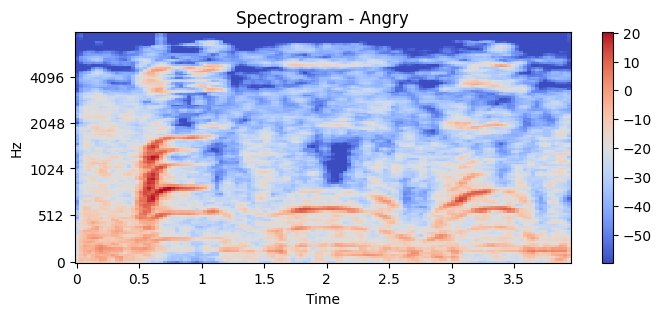

🎵 Plotting for: /content/cat_audio_clean/Mating/cat_youtube64304.wav


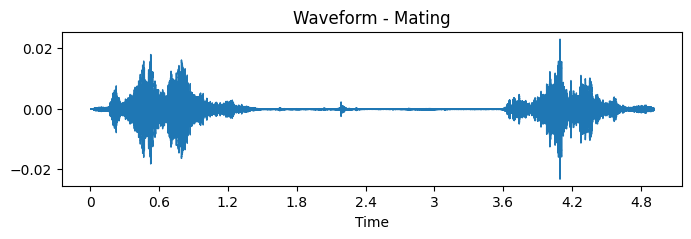

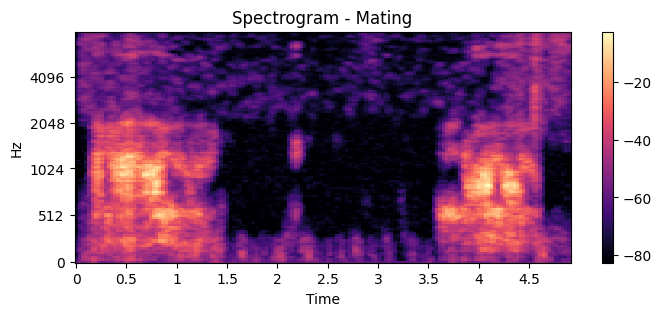

 No audio files found in: /content/cat_audio_clean/CAT_DB
🎵 Plotting for: /content/cat_audio_clean/Paining/car_extcoll0247.wav


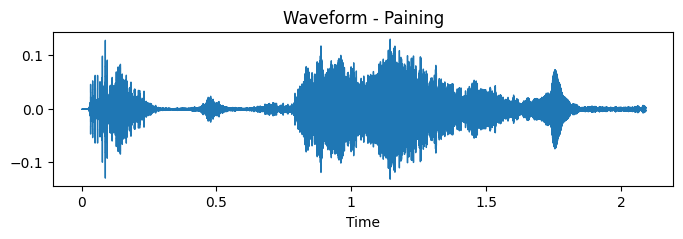

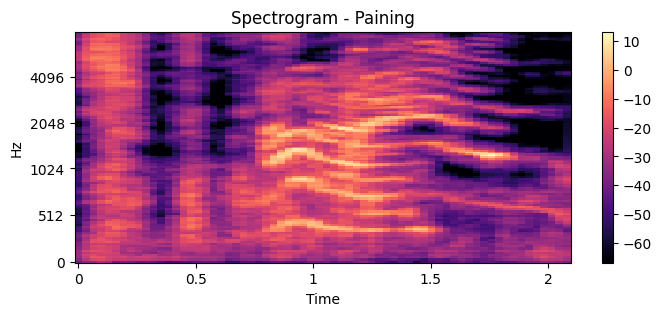

🎵 Plotting for: /content/cat_audio_clean/MotherCall/cat_coll0141.wav


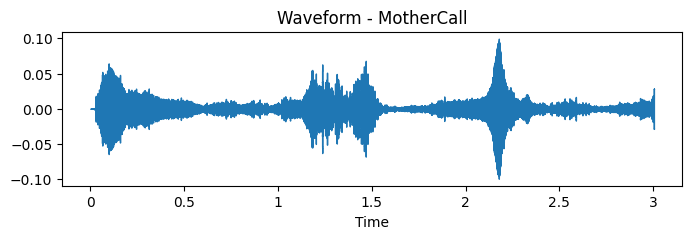

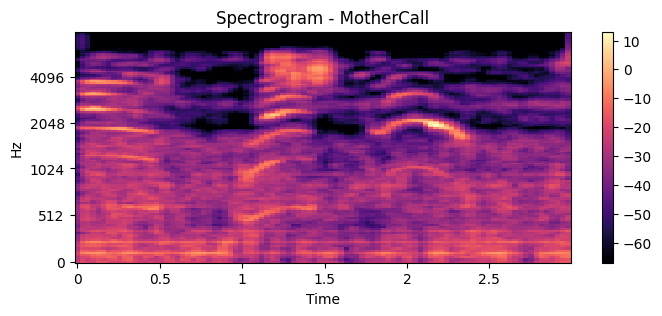

🎵 Plotting for: /content/cat_audio_clean/Defense/car_extcoll0235.wav


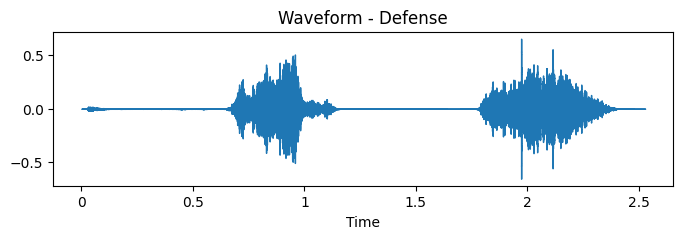

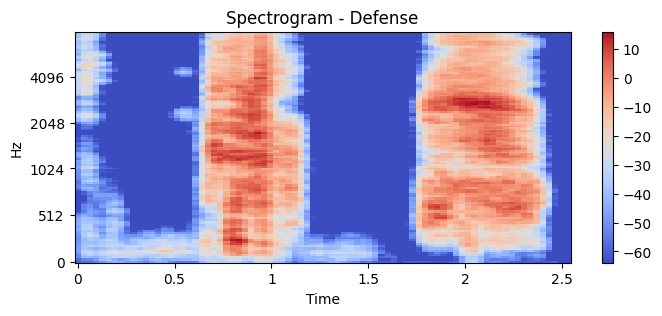

🎵 Plotting for: /content/cat_audio_clean/Warning/car_extcoll0213.wav


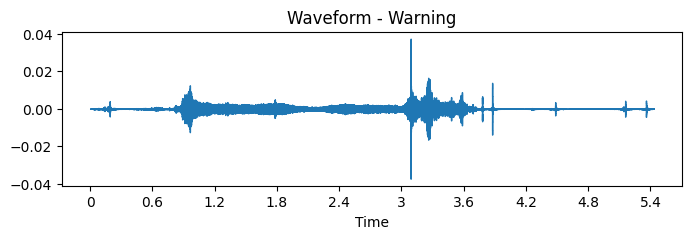

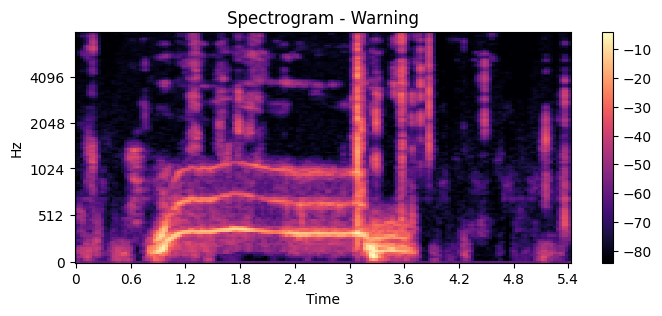

🎵 Plotting for: /content/cat_audio_clean/Happy/cat_75.wav


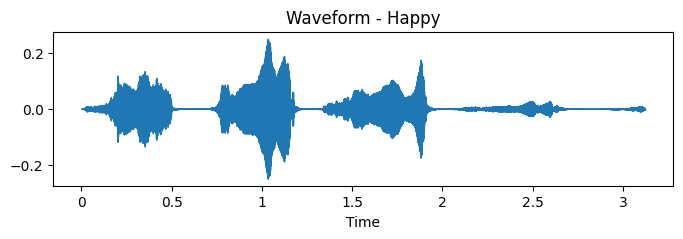

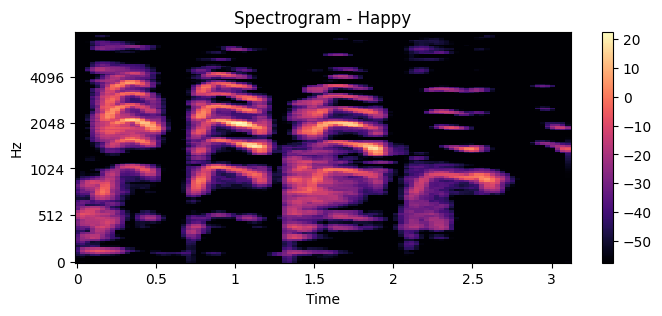

🎵 Plotting for: /content/cat_audio_clean/HuntingMind/car_extcoll0326.wav


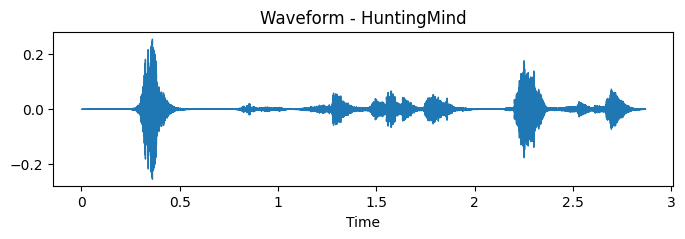

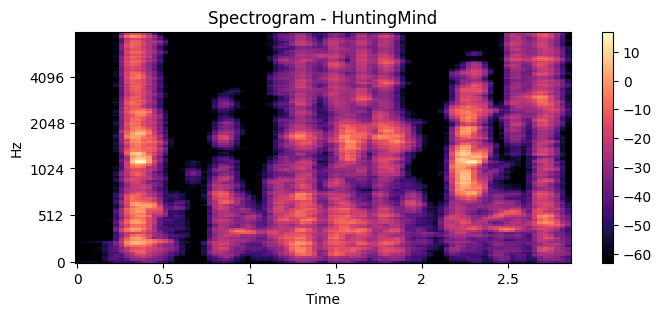

🎵 Plotting for: /content/cat_audio_clean/Fighting/car_extcoll0143.wav


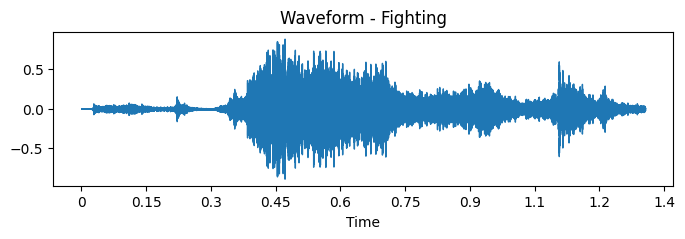

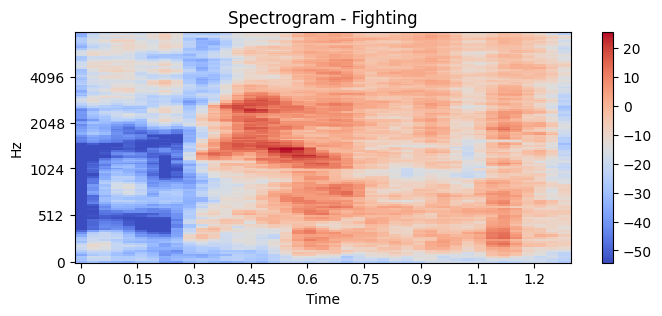

In [22]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt

AUDIO_CLEAN = "/content/cat_audio_clean"

valid_ext = (".wav", ".mp3", ".ogg", ".aac", ".m4a")

for cls in os.listdir(AUDIO_CLEAN):
    cls_path = os.path.join(AUDIO_CLEAN, cls)
    if not os.path.isdir(cls_path):
        continue

    # Get only audio files
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(".wav")]

    if len(files) == 0:
        print(f" No audio files found in: {cls_path}")
        continue  # skip this class safely

    # Pick first file
    file = files[0]
    path = os.path.join(cls_path, file)

    print("🎵 Plotting for:", path)

    try:
        y, sr = librosa.load(path, sr=16000)
    except Exception as e:
        print(" Could not load file:", e)
        continue

    # Waveform
    plt.figure(figsize=(8,2))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform - {cls}")
    plt.show()

    # Mel Spectrogram (use safe function alias)
    from librosa.feature import melspectrogram as real_melspectrogram
    S = real_melspectrogram(y=y, sr=sr)
    S_db = librosa.power_to_db(S)

    plt.figure(figsize=(8,3))
    librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel")
    plt.title(f"Spectrogram - {cls}")
    plt.colorbar()
    plt.show()
